In [ ]:
# !pip install dwave-neal

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os, re, glob
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from tqdm import  tqdm
import neal

# Straight-ray forward model: $\mathbf{D}\,\mathbf{s} = \mathbf{T}$

$$
\underbrace{\begin{bmatrix}
d_{11} & d_{12} & \cdots & d_{1N}\\
d_{21} & d_{22} & \cdots & d_{2N}\\
\vdots & \vdots & \ddots & \vdots\\
d_{M1} & d_{M2} & \cdots & d_{MN}
\end{bmatrix}}_{\mathbf{D}\in\mathbb{R}^{M\times N}}
\underbrace{\begin{bmatrix}
s_1\\
s_2\\
\vdots\\
s_N
\end{bmatrix}}_{\mathbf{s}\in\mathbb{R}^{N}}
=
\underbrace{\begin{bmatrix}
T_1\\
T_2\\
\vdots\\
T_M
\end{bmatrix}}_{\mathbf{T}\in\mathbb{R}^{M}}
$$

- $d_{ij}$: length of ray $i$ inside cell $j$ (m)  
- $s_j = 1/v_j$: slowness in cell $j$ (s/m)  
- $T_i$: traveltime of ray $i$ (s)

---

The unknowns $s_j$ are **real values** (slowness), but to solve this with a QUBO/annealer we must work with **binary variables**.  

Therefore, each $s_j$ is approximated by a binary expansion using $n$ bits:
$$
s_j \;\approx\; \sum_{k=0}^{n-1} q_{j,k}\,2^{\,j_0-k-1},\qquad q_{j,k}\in\{0,1\}.
$$

Stacking all bits into a long vector $\mathbf{q}\in\{0,1\}^{Nn}$, we construct a new matrix $\mathbf{A}$ so that
$$
\mathbf{A}\,\mathbf{q} = \mathbf{b},
$$
with
- $\mathbf{A} \in \mathbb{R}^{M\times (Nn)}$ built by replicating and weighting columns of $\mathbf{D}$,
- $\mathbf{q}$ the binary variables,
- $$
\mathbf{b} \;=\; \frac{\mathbf{T} \;+\; L\,\mathbf{D}\,\mathbf{I} \;-\; \mathbf{D}\,\mathbf{s}_0}{L}.
$$

---

# Functions needed in this tutorial

To convert the straight-ray system $\mathbf{D}\mathbf{s} = \mathbf{T}$ into a binary QUBO form $\mathbf{A}\mathbf{q} = \mathbf{b}$, we need a few main functions.  
Other helper functions will be provided separately, but the core ones are:

- **`binary2real`**  
  Convert a binary vector $\mathbf{q}$ back into its real-valued approximation.

- **`constructAd`**  
  Build the expanded binary matrix $\mathbf{A}$ from the original path-length matrix $\mathbf{D}$, based on the chosen bit representation.

- **`binary_least_squares_qubo`**  
  Compute the optimal binary solution.

- **`quantum_annealing_inversion`**  
  Compute the inversion with iterations.

These are the essential steps to go from the continuous formulation $\mathbf{D}\mathbf{s}=\mathbf{T}$ to the binary formulation $\mathbf{A}\mathbf{q}=\mathbf{b}$, which can then be turned into a QUBO problem.


# `binary2real(binary_vector, n_bits, j0)`

We want to reconstruct real values from their binary fixed-point representation.

Suppose each real $x$ is encoded with $n$ bits:
$$
q = [q_0, q_1, \dots, q_{n-1}], \qquad q_k \in \{0,1\}.
$$

The function interprets this bit string (with the last element being the least significant bit) as
$$
s_j \;\approx\; \sum_{k=0}^{n-1} q_{j,k}\,2^{\,j_0-k-1},\qquad q_{j,k}\in\{0,1\}.
$$

Here:
- $n$ = number of bits used
- $j_0$ = fixed-point position (shifts the binary point)

If the binary vector contains multiple numbers, it is split into consecutive blocks of $n$ bits, and each block is converted with the formula above.




We have 10 bits:

$$
[01011001 \;|\; 10]
$$

with the fixed point at $j_0 = 8$.


$$
01011001 \;|\; 10
= 0\cdot 2^7
+ 1\cdot 2^6
+ 0\cdot 2^5
+ 1\cdot 2^4
+ 1\cdot 2^3
+ 0\cdot 2^2
+ 0\cdot 2^1
+ 1\cdot 2^0
+ 1\cdot 2^{-1}
+ 0\cdot 2^{-2}
$$

$$
= 89.5
$$


Example (with $n=4$, $j_0=2$):

Bits $[1,0,1,1]$ give
$$
x \;=\; 1\cdot 2^{3-2} \;+\; 0\cdot 2^{2-2} \;+\; 1\cdot 2^{1-2} \;+\; 1\cdot 2^{0-2}
\;=\; 2 \;+\; 0 \;+\; \tfrac{1}{2} \;+\; \tfrac{1}{4}
\;=\; 2.75.
$$


In [ ]:
# Not that this one use compute from the left
# Not be used

def real2binary(x, n_bits, j0):
    """
    Discretize a real-valued vector x using b-bit fixed point approximation.

    Args:
    x (np.ndarray): The real-valued vector to be discretized.
    b (int): The number of bits for the fixed point binary representation.
    j0 (int): The position of the fixed point, with 0 being the least significant bit.

    Returns:
    np.ndarray: The binary vector representing the discretized version of x.
    """
    # Scale x by 2^(b-j0) to move the fixed point
    scaled_x = x * (2 ** (n_bits - j0))
    # Round the scaled values to the nearest integer
    int_x = np.rint(scaled_x).astype(int)
    # Ensure the integer values are within the allowed range for the b-bit representation
    max_int = 2 ** n_bits - 1
    int_x_clipped = np.clip(int_x, 0, max_int)
    # Convert the integer values to binary strings, remove the '0b' prefix, and zero-pad to b bits
    binary_x = [format(val, f'0{n_bits}b') for val in int_x_clipped]
    # Flatten the binary strings into a single binary vector
    binary_vector = np.array([int(bit) for bin_str in binary_x for bit in bin_str])

    return binary_vector

### Example: using `real2binary`

Suppose  
- $x = [1.3,\, 0.6]$  
- $n_{\text{bits}} = 4$  
- $j_0 = 3$

**Scale and round**
$$
\text{scale} = 2^{\,n-j_0} = 2^{\,4-3} = 2, \qquad
\text{scaled}_x = [1.3,\,0.6]\times 2 = [2.6,\,1.2].
$$
Rounded to integers:
$$
\text{int}_x = [3,\,1].
$$

**Clip to $[0,\,2^4-1]=[0,\,15]$**  
Already within range.

**Convert to 4-bit binary (MSB→LSB)**
- $3 \;\to\; 0011$
- $1 \;\to\; 0001$

**Flatten**
$$
q = [0,0,1,1,\,0,0,0,1].
$$

So the function returns the binary vector
$$
q = \begin{bmatrix}0 & 0 & 1 & 1 & 0 & 0 & 0 & 1\end{bmatrix}.
$$


In [ ]:
real2binary(np.array([1.3, 0.6]), 4, 3)

array([0, 0, 1, 1, 0, 0, 0, 1])

# Math behind `binary2real(binary_vector, n_bits, j0)`

We want to reconstruct real values from their binary fixed-point representation.

Suppose each real $x$ is encoded with $n$ bits:
$$
q = [q_0, q_1, \dots, q_{n-1}], \qquad q_k \in \{0,1\}.
$$

The function interprets this bit string (with the last element being the least significant bit) as
$$
x \;=\; \sum_{k=0}^{n-1} q_k \, 2^{\,k - j_0}.
$$

Here:
- $n$ = number of bits used
- $j_0$ = fixed-point position (shifts the binary point)

If the binary vector contains multiple numbers, it is split into consecutive blocks of $n$ bits, and each block is converted with the formula above.

Example (with $n=4$, $j_0=2$):

Bits $[1,0,1,1]$ give
$$
x \;=\; 1\cdot 2^{3-2} \;+\; 0\cdot 2^{2-2} \;+\; 1\cdot 2^{1-2} \;+\; 1\cdot 2^{0-2}
\;=\; 2 \;+\; 0 \;+\; \tfrac{1}{2} \;+\; \tfrac{1}{4}
\;=\; 2.75.
$$



In [ ]:

def binary2real(binary_vector, n_bits, j0):
    """
    Convert a binary vector to a real number using n-bit fixed point representation.

    Args:
        binary_vector (np.ndarray): The binary vector to be converted.
        n_bits (int): The number of bits used for the fixed point representation.
        j0 (int): The position of the fixed point.

    Returns:
        np.ndarray: The real number representation of the binary vector.
    """
    # Determine the number of elements in the real number vector

    num_elements = len(binary_vector) // n_bits

    # Initialize the real number vector
    real_vector = np.zeros(num_elements)

    # Extract the real number from the binary representation
    for i in range(num_elements):
        # Extract the binary representation of the current real number
        binary_repr = binary_vector[i * n_bits:(i + 1) * n_bits]

        # Convert binary to integer, taking into account the fixed point position
        int_value = 0
        for bit_pos, bit in enumerate(reversed(binary_repr)):
            # Your code starts here
            # 1 line of code to compute decimal value from binary string
            int_value += bit * (2 ** (bit_pos - j0))
            # Your code ends here

        # Add the integer value to the real number vector
        real_vector[i] = int_value

    return real_vector

In [ ]:
binary2real(np.array([1,0,1,1]  ), 4, 2)

array([2.75])

# Constructing the binary matrix $\mathbf{A}$ for $\mathbf{D}\mathbf{s}=\mathbf{T}$

Starting from
$$
\mathbf{D}\,\mathbf{s} = \mathbf{T},\quad
\mathbf{D}\in\mathbb{R}^{M\times N},\
\mathbf{s}\in\mathbb{R}^N,\
\mathbf{T}\in\mathbb{R}^M,
$$

represent each slowness by $n$ bits:
$$
s_i \;\approx\; \sum_{j=0}^{n-1} q_{i,j}\,2^{\,j_0-j-1},
\qquad q_{i,j}\in\{0,1\}.
$$

To form the binary system $\mathbf{A}\mathbf{q}=\mathbf{T}$, create
$\mathbf{A}\in\mathbb{R}^{M\times (Nn)}$ by **replicating columns of $\mathbf{D}$ with weights**
$$
\mathbf{A}[:,\, i\,n + j] \;
=\; \mathbf{D}[:,\,i]\;2^{\,j_0-j-1},
\qquad i=0,\dots,N-1,\; j=0,\dots,n-1.
$$




In [ ]:
# Function to construct the Ad matrix given A and n
def construct_Ad(A, n, j0):
    N, M = A.shape  # Number of rows and original number of columns in A
    Ad = np.zeros((N, M * n))  # Initialize Ad with the correct shape


    # Your code starts here
    # # lines of code with loop in loop
    for i in range(M):
        for j in range(n):
            # Construct the columns of Ad based on A and the bit significance
            Ad[:, i * n + j] = A[:, i] * (2 ** (j0 - j - 1))

    # Your code ends here

    # The original code which follows the paper should return Ad.
    # However, after multiple tries, I come up with return Ad/2.
    return Ad


# `binary_least_squares_qubo(A, b)`

We want a QUBO for the binary least‐squares problem
$$
\min_{q\in\{0,1\}^n}\;\|\mathbf{A}q - \mathbf{b}\|_2^2,
\qquad \mathbf{A}\in\mathbb{R}^{M\times n},\;\mathbf{b}\in\mathbb{R}^{M}.
$$

Expand the square:
$$
\|\mathbf{A}q-\mathbf{b}\|_2^2
= (\mathbf{A}q-\mathbf{b})^\top(\mathbf{A}q-\mathbf{b})
= q^\top \mathbf{A}^\top \mathbf{A}\, q \;-\; 2\, \mathbf{b}^\top \mathbf{A}\, q \;+\; \mathbf{b}^\top \mathbf{b}.
$$

The constant term $\mathbf{b}^\top \mathbf{b}$ does **not** affect the minimizer, so the QUBO objective is
$$
E(q) \equiv q^\top \mathbf{A}^\top \mathbf{A}\, q \;-\; 2\, (\mathbf{A}^\top \mathbf{b})^\top q.
$$

Let
$$
\mathbf{H} := \mathbf{A}^\top \mathbf{A} \in \mathbb{R}^{n\times n},
\qquad
\mathbf{g} := \mathbf{A}^\top \mathbf{b} \in \mathbb{R}^{n}.
$$
Then
$$
E(q) = \sum_{i=1}^n \sum_{j=1}^n H_{ij}\, q_i q_j \;-\; 2 \sum_{i=1}^n g_i\, q_i.
$$

To store this as a QUBO dictionary on the **upper triangle** $(i\le j)$:

- **Diagonal terms** ($i=j$):
  $$
  Q_{ii} = H_{ii} - 2 g_i.
  $$
- **Off–diagonal terms** ($i<j$):
  $$
  Q_{ij} = 2\, H_{ij}.
  $$

So the energy the solver minimizes is
$$
E(q) \;=\; \sum_{i\le j} Q_{ij}\, q_i q_j \quad (+\;\text{dropped constant } \mathbf{b}^\top \mathbf{b}).
$$

**How to do it**
1. Compute $\mathbf{H}=\mathbf{A}^\top \mathbf{A}$ and $\mathbf{g}=\mathbf{A}^\top \mathbf{b}$.
2. For each variable index $i$:
   - set $Q_{ii}=H_{ii}-2g_i$.
3. For each pair $i<j$:
   - set $Q_{ij}=2H_{ij}$.
4. Feed $\{Q_{ij}\}$ to your QUBO solver; constants don’t matter.


In [ ]:
def binary_least_squares_qubo(A, b):
    """
    Transforms the binary least squares problem into a QUBO problem.
    Args:
        A (np.ndarray): The matrix A in the binary least squares problem.
        b (np.ndarray): The vector b in the binary least squares problem.
    Returns:
        dict: The QUBO coefficients.
    """
    # Number of variables
    n = A.shape[1]


    # Your code starts here
    # 2 lines of code to compute A^T * A and A^T * b
    ATA = A.T @ A
    ATb = A.T @ b
    # Your code ends here

    # Initialize the QUBO dictionary
    Q = {}

    # Fill the QUBO coefficients
    for i in range(n):
        for j in range(i, n):

            # Your code starts here
            # 4 lines of code with conditions for Diagonal/Off-diagonal entries
            if i == j:  # Diagonal entries
                Q[(i, i)] = ATA[i, i] - 2 * ATb[i]
            else:  # Off-diagonal entries
                Q[(i, j)] = 2 * ATA[i, j]
            # Your code ends here

    return Q

**Data Generator and Other supporting functions**

In [ ]:
# from dwave.system import DWaveSampler, EmbeddingComposite # type: ignore
"""
Dwave sampler is an object that represents the quantum annealer itself. It is responsible for directly interacting with the quantum hardware.
When you create an instance of DWaveSampler, you are preparing to submit your optimization problem to a D-Wave quantum annealer for solution.

EmbeddingComposite is a wrapper around samplers that automatically handles the problem of embedding. Embedding is the process of mapping your
problem from its logical representation to the physical representation.
"""

def dict_to_vector_auto(q_dict):
    """
    Convert a solution dictionary from a QUBO problem into a vector representation.

    Args:
        q_dict (dict): The solution dictionary where keys are variable indices and values are the binary values.

    Returns:
        np.ndarray: The vector representation of the solution.
    """
    # Determine the size of the vector (n) based on the highest index in q_dict
    n = max(q_dict.keys()) + 1

    # Initialize a vector of size n with zeros
    q_vector = np.zeros(n, dtype=int)

    # Populate the vector with the values from the solution dictionary
    for i, value in q_dict.items():
        q_vector[i] = value

    return q_vector



def find_intersections(sources, receivers, grid_size):
    """
    Find intersection points between source-receiver lines and grid cell boundaries.

    Parameters:
        sources (list): List of source coordinates [(x0, y0), ...].
        receivers (list): List of receiver coordinates [(x1, y1), ...].
        grid_size (tuple): Grid size as (rows, columns).

    Returns:
        list: List of intersection points for each source-receiver pair.
    """
    all_intersections = []
    for s_idx, source in enumerate(sources):
        for i, receiver in enumerate(receivers):
            x0, y0 = source
            x1, y1 = receiver
            dx = x1 - x0
            dy = y1 - y0

            for j in range(grid_size[0]):  # Loop over rows
                for k in range(grid_size[1]):  # Loop over columns
                    # Define grid cell boundaries
                    cell_x_min = k
                    cell_x_max = k + 1
                    cell_y_min = j
                    cell_y_max = j + 1
                    intersections = []

                    # Calculate intersection with the left boundary
                    if dx != 0:
                        t = (cell_x_min - x0) / dx
                        if 0 <= t <= 1:
                            y = y0 + t * dy
                            if cell_y_min <= y <= cell_y_max:
                                intersections.append((cell_x_min, y))

                    # Calculate intersection with the right boundary
                    if dx != 0:
                        t = (cell_x_max - x0) / dx
                        if 0 <= t <= 1:
                            y = y0 + t * dy
                            if cell_y_min <= y <= cell_y_max:
                                intersections.append((cell_x_max, y))

                    # Calculate intersection with the bottom boundary
                    if dy != 0:
                        t = (cell_y_min - y0) / dy
                        if 0 <= t <= 1:
                            x = x0 + t * dx
                            if cell_x_min <= x <= cell_x_max:
                                intersections.append((x, cell_y_min))

                    # Calculate intersection with the top boundary
                    if dy != 0:
                        t = (cell_y_max - y0) / dy
                        if 0 <= t <= 1:
                            x = x0 + t * dx
                            if cell_x_min <= x <= cell_x_max:
                                intersections.append((x, cell_y_max))

                    # Add entry and exit points
                    if (cell_x_min <= x0 <= cell_x_max) and (cell_y_min <= y0 <= cell_y_max):
                        intersections.append((x0, y0))
                    if (cell_x_min <= x1 <= cell_x_max) and (cell_y_min <= y1 <= cell_y_max):
                        intersections.append((x1, y1))

                    # Remove duplicate points
                    intersections = list(set(intersections))
                    # Sort intersections by distance from the source
                    intersections = sorted(intersections, key=lambda p: np.hypot(p[0] - x0, p[1] - y0))

                    # Add intersections to all_intersections
                    all_intersections.append(intersections)

    return all_intersections

# Remove duplicate intersection points
def remove_duplicate_intersections(intersections):
    """
    Remove duplicate intersection points.

    Parameters:
        intersections (list): List of intersection points.

    Returns:
        list: List of unique intersection points.
    """
    seen = set()
    unique_intersections = []

    for point_pair in intersections:
        if tuple(point_pair) not in seen:
            unique_intersections.append(point_pair)
            seen.add(tuple(point_pair))
        else:
            unique_intersections.append([])

    return unique_intersections

# Calculate distances based on intersection points
def calculate_distances(unique_intersections, grid_size, sources, receivers):
    """
    Calculate total distances along paths defined by unique intersection points.

    Parameters:
        unique_intersections (list): Unique intersection points.
        grid_size (tuple): Grid size as (rows, columns).
        sources (list): List of source coordinates.
        receivers (list): List of receiver coordinates.

    Returns:
        np.ndarray: 4D array of distances for each grid cell, receiver, and source.
    """
    distances = np.zeros((grid_size[0], grid_size[1], len(receivers), len(sources)))
    idx = -1
    for s_idx, source in enumerate(sources):
        for i, receiver in enumerate(receivers):
            for j in range(grid_size[0]):
                for k in range(grid_size[1]):
                    idx = idx + 1
                    intersections = unique_intersections[idx]
                    if len(intersections) >= 2:
                        total_distance = 0
                        for idxx in range(len(intersections) - 1):
                            d = np.hypot(intersections[idxx + 1][0] - intersections[idxx][0], intersections[idxx + 1][1] - intersections[idxx][1])
                            total_distance += d
                        distances[j, k, i, s_idx] = total_distance
                    else:
                        distances[j, k, i, s_idx] = 0
    return distances

def rescale(arr, new_min, new_max):
    """
    Rescale an array to a specified range.

    Parameters:
        arr (np.ndarray): Input array.
        new_min (float): New minimum value.
        new_max (float): New maximum value.

    Returns:
        np.ndarray: Rescaled array.
    """
    old_min = np.min(arr)
    old_max = np.max(arr)
    return (new_max - new_min) * (arr - old_min) / (old_max - old_min) + new_min

def device_location(n, rows, new_min, new_max, linear):
    """
    Generate device locations with linear or quadratic distribution.

    Parameters:
        n (int): Number of devices.
        rows (int): Number of rows in the grid.
        new_min (float): Minimum location value.
        new_max (float): Maximum location value.
        linear (bool): If True, generate linearly spaced locations; otherwise, use quadratic scaling.

    Returns:
        np.ndarray: Array of device locations.
    """
    if linear:
        return np.linspace(new_min, new_max, n)

    n2 = int(np.ceil(n / 2))
    center = rows / 2.0

    x = np.arange(n2)
    y = (x + 3)**2
    # spread the upper-half around the center
    span = max(center - 1.3, 1.0)
    z = (y - y[0]) * span / (y[-1] - y[0])

    # mirror around center
    z1 = center - z + center
    z2 = z1[::-1]
    z3 = np.concatenate((z, z2))[:n]  # ensure exactly n values

    return rescale(z3, new_min, new_max)

def noise_generator(size, noise_level):
    """
    Generate random noise within a specified range.

    Parameters:
        size (int): Size of the noise array.
        noise_level (float): Magnitude of the noise.

    Returns:
        np.ndarray: Generated noise array.
    """
    noise = (np.random.rand(size)) - 0.5
    noise = noise * noise_level
    return noise

**Download Marmousi Data from Denise Repository**

In [ ]:
def load_bin(p, dims):
    f = open(p); vp = np.fromfile (f, dtype=np.dtype('float32').newbyteorder ('<')); f.close();
    vp = vp.reshape(*dims); vp = np.transpose(vp); vp = np.flipud(vp); print(f"{vp.shape}"); return vp

# import pyapi_denise as api

!wget https://github.com/daniel-koehn/DENISE-Benchmark/raw/master/Marmousi-II/start/marmousi_II_marine.vp -P ./velocity_model/


dx = 20.0  # m (assume same spacing vertically)
vp = load_bin('./velocity_model/marmousi_II_marine.vp', (500, 174))

print(vp.shape);

--2025-08-24 09:30:13--  https://github.com/daniel-koehn/DENISE-Benchmark/raw/master/Marmousi-II/start/marmousi_II_marine.vp
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/daniel-koehn/DENISE-Benchmark/master/Marmousi-II/start/marmousi_II_marine.vp [following]
--2025-08-24 09:30:13--  https://raw.githubusercontent.com/daniel-koehn/DENISE-Benchmark/master/Marmousi-II/start/marmousi_II_marine.vp
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 348000 (340K) [application/octet-stream]
Saving to: ‘./velocity_model/marmousi_II_marine.vp.14’

marmousi_II_marine. 100%[===================>] 339.84K  --.

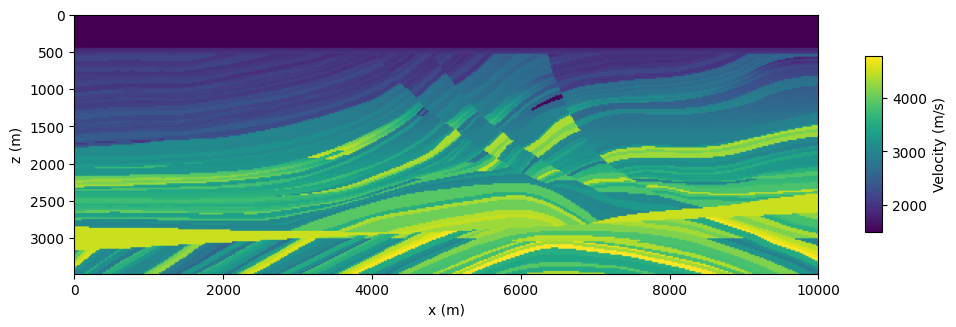

In [ ]:
dx = 20   # grid spacing in x
dz = 20   # grid spacing in z
nz = vp.shape[0]
nx = vp.shape[1]
# extent = [x_min, x_max, z_min, z_max]
extent = [0, nx*dx, nz*dz, 0]

plt.figure(figsize=(12,6))
plt.imshow(vp, origin='lower', extent=extent)
cbar = plt.colorbar(shrink=0.38, aspect=10)
cbar.set_label("Velocity (m/s)")

plt.xlabel("x (m)")
plt.ylabel("z (m)")
plt.show()

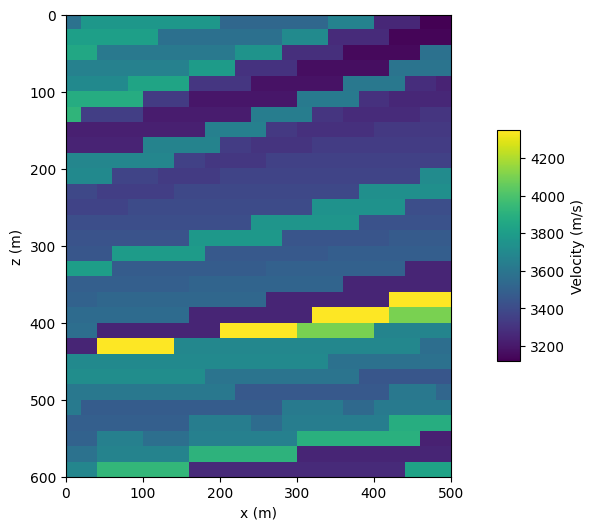

In [ ]:

# Cut rows to get smaller size vp[45:75, 150:175]

vp_cut = vp[45:75, 150:175]   # end index is exclusive -> 401

nz = vp_cut.shape[0]
nx = vp_cut.shape[1]
extent = [0, nx*dx, nz*dx, 0]

plt.figure(figsize=(12,6))
plt.imshow(vp_cut, origin='lower', extent=extent)
cbar = plt.colorbar(shrink=0.5, aspect=10)
cbar.set_label("Velocity (m/s)")

plt.xlabel("x (m)")
plt.ylabel("z (m)")
plt.show()

# Quantum Annealing Inversion

The function `quantum_annealing_inversion` performs velocity inversion using quantum annealing (simulated annealing with `neal` by default). It follows these main steps:

---

## Parameters
- **noise_level (float)**: magnitude of noise applied to traveltime data.  
- **results_dir (str)**: directory to save inversion results.  
- **velocity_model (ndarray)**: 2D velocity model (rows × cols).  

---

## Workflow

### Part 1 – Velocity slice and geometry
- Loop through each depth row (`layer`).  
- Extract a slice of the velocity model, `velocity_01`.  
- Place sources on the left boundary and receivers on the right boundary using `device_location`.  
- Compute intersections between rays and the grid with `find_intersections` → `remove_duplicate_intersections` → `calculate_distances`.

### Part 2 – Build $\mathbf{D}$ and $\mathbf{T}$
- Build **matrix $\mathbf{D}$** (ray × cell path lengths).  
- Build **vector $\mathbf{T}$** (traveltimes) using  
  $$
  T_{i,j} = \sum_{\text{cells}} \text{distance}_{i,j} \cdot s
  $$  
  where $\mathbf{s} = 1/\mathbf{v}$ is slowness.

### Part 3 – Add noise and clean
- Add random noise to $\mathbf{T}$ with `noise_generator`.  
- Remove rays with zero traveltime.  
- Final system: $\mathbf{D}_{\text{new}}, \mathbf{T}_{\text{new}}$.

### Part 4 – Prepare annealer parameters
- Define matrix $\mathbf{M} = \mathbf{D}_{\text{new}}$, traveltime vector $\mathbf{t} = \mathbf{T}_{\text{new}}$.  
- Use $\mathbf{I} = \mathbf{1}$ (vector of ones).  
- Choose number of bits $R$ (e.g., $R=3$).  
- Initial guess: $\mathbf{s}_0 = 1/3500$ (s/m).  
- Build expanded binary matrix $\mathbf{A} = \texttt{constructAd}(\mathbf{M}, R, j_0=1)$.  
- Set step size $L=5\times 10^{-5}$.

### Part 5 – Quantum Annealing iterations
For 10 iterations:
1. Build right-hand side  
   $$
   \mathbf{b} = \frac{\mathbf{t} + L(\mathbf{M}\mathbf{I}) - \mathbf{M}\mathbf{s}_0}{L}.
   $$
2. Construct QUBO with `binary_least_squares_qubo(A, b)`.  
3. Solve QUBO with `neal.SimulatedAnnealingSampler()`.  
4. Extract best sample:  
   - Convert dictionary → vector (`dict_to_vector_auto`).  
   - Decode bits to real vector (`binary2real`).  
5. Update slowness:  
   $$
   \mathbf{s} = \mathbf{s}_0 + L(\mathbf{x} - \mathbf{I}).
   $$
6. Save $\mathbf{s}$ to file, halve $L$, and repeat.

---

## Outputs
- For each layer, the updated slowness estimates are written to text files:  


**Estimated run time: 3m**

In [ ]:
def quantum_annealing_inversion(noise_level, results_dir='results30x10-new', velocity_model=None):
    """
    Perform velocity inversion using quantum annealing with specified noise level.

    Parameters:
    noise_level (float): The noise level to be applied to travel time data.
    results_dir (str): Directory to store the results.

    Returns:
    None
    """
    # Define the velocity model
    rows, cols = velocity_model.shape
    grid_size = (rows, cols)
    n_device = 20

    # Iterate through layers
    for layer in tqdm(range(0, rows), desc="Process", colour='green'):

        # -----------------------------------------------------------------
        # Part 1 - Extract a part of the velocity model and set up geometry
        velocity_01 = velocity_model[layer, :]
        velocity_01 = velocity_01.reshape(1, -1)

        rows_new, cols_new = 1, cols
        grid_size_new = (rows_new, cols_new)

        z = device_location(n=n_device, rows=rows, new_min=0.1, new_max=rows - 0.1, linear=False)

        z = z - layer
        sources = [(0, i) for i in z]
        receivers = [(cols, i) for i in z]



        intersections = find_intersections(sources, receivers, grid_size=grid_size_new)
        unique_intersections = remove_duplicate_intersections(intersections)
        distances = calculate_distances(unique_intersections, grid_size=grid_size_new, sources=sources, receivers=receivers)


        # -----------------------------------------------------------------
        # Part 2 - Calculate D and T for least squares
        D = []
        T = []
        s1 = 1 / velocity_01

        nreceiver = len(receivers)
        nsource = len(sources)

        for i in range(nsource):
            for j in range(nreceiver):
                D.append(distances[:, :, j, i].flatten())
                T.append(sum(sum(distances[:, :, j, i] * s1)))
        D = np.array(D)
        s1 = s1.flatten()

        # -----------------------------------------------------------------
        # Part 3 - Add noise and remove zero elements
        T = np.array(T)
        indices_of_zero_np = np.where(T == 0)[0]

        # Add noise
        noise_percent = noise_generator(size=400, noise_level=noise_level)
        T_noise = T + noise_percent * T

        T_new = np.delete(T_noise, indices_of_zero_np, axis=0)
        D_new = np.delete(D, indices_of_zero_np, axis=0)

        # -----------------------------------------------------------------
        # Part 4 - Prepare parameters for quantum annealing

        M = D_new.copy()
        I = np.ones(M.shape[1])
        R = 3
        t = T_new.copy()

        # -----------------------------------------------------------------
        # Part 5 - Quantum Annealing


        # Intial guess for s0 with velocity = 3500 ms.s
        # Your code starts here
        # 1 line of code
        s0 = np.ones(s1.shape) * 1 / 3500
        # Your code ends here

        # Compute A matrix
        # Your code starts here
        # 1 line of code
        A = construct_Ad(M, R, 1)
        # Your code ends here

        # choose boundary for L
        L = 5e-5
        directory = f'{results_dir}/{layer}'
        os.makedirs(directory, exist_ok=True)

        for i in range(0, 10): # 10 loops



            # follow step 5 to update s
            # compute b,
            # compute Q,
            # compute q by:
              # sampler = neal.SimulatedAnnealingSampler()
              # sampleset = sampler.sample_qubo(Q, num_reads=100)
              # q = dict_to_vector_auto(sampleset.first.sample)

            # compute x
            # update s = f(s0)
            # update s0 = s
            # update L

            # Your code starts here
            # ~10 lines of code
            # Your code ends here

            b = (t + L * M @ I - M @ s0) / L

            Q = binary_least_squares_qubo(A, b)

            # Solve the QUBO using D-Wave's system
            sampler = neal.SimulatedAnnealingSampler()
            sampleset = sampler.sample_qubo(Q, num_reads=100)

            # Get the best sample
            q = dict_to_vector_auto(sampleset.first.sample)
            x = binary2real(q, R, 2)

            # Update s
            s = s0 + L * (x - I)

            # Save results
            s0 = s
            L = L / 2


            # save file
            filename = f'{directory}/s_{i}.txt'
            np.savetxt(filename, s)

In [ ]:


# Run the function just created!
# Your code starts here
# 1 line of code
# Your code starts here



quantum_annealing_inversion(noise_level=1e-2, results_dir='results-noise-1-constantL', velocity_model=vp_cut)


Process: 100%|██████████| 30/30 [02:48<00:00,  5.61s/it]


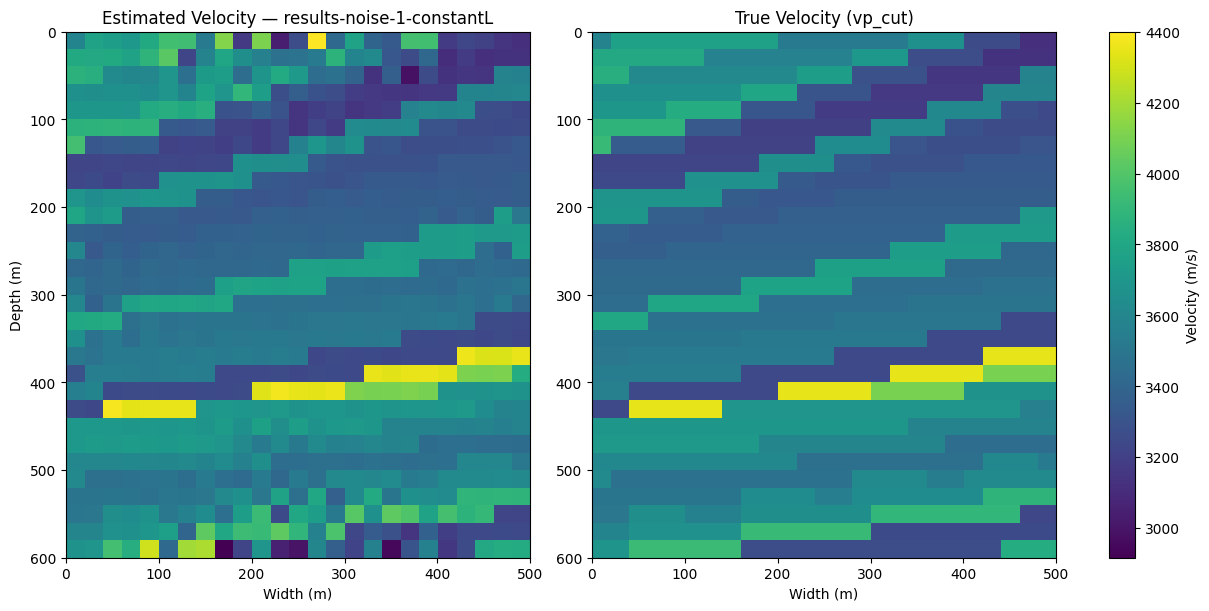

In [ ]:
def plot_layered_results(results_dir='results-noise-1-constantL', dx=20.0, v_true=None, cols_expected=None):
    import glob, re
    from collections import Counter

    # find numeric layer folders
    layer_dirs = [d for d in os.listdir(results_dir)
                  if os.path.isdir(os.path.join(results_dir, d)) and d.isdigit()]
    if not layer_dirs:
        raise RuntimeError(f"No numeric layer folders in {results_dir}")
    layer_ids = sorted(int(d) for d in layer_dirs)

    # read last s_*.txt from each layer
    rows_data = []     # (layer_id, s_row)
    lengths = []
    for lid in layer_ids:
        dpath = os.path.join(results_dir, str(lid))
        files = glob.glob(os.path.join(dpath, "s_*.txt"))
        if not files:
            continue
        files.sort(key=lambda p: int(re.search(r"s_(\d+)\.txt", os.path.basename(p)).group(1)))
        s_row = np.loadtxt(files[-1]).ravel()
        rows_data.append((lid, s_row))
        lengths.append(s_row.size)

    # choose expected width
    if cols_expected is None and v_true is not None:
        cols_expected = v_true.shape[1]
    if cols_expected is None:
        cols_expected = Counter(lengths).most_common(1)[0][0]  # mode

    # keep only layers matching expected width
    rows_data = [(lid, s) for (lid, s) in rows_data if s.size == cols_expected]
    if not rows_data:
        raise RuntimeError(f"No layers with width {cols_expected}. Found widths: {sorted(set(lengths))}")

    rows_data.sort(key=lambda x: x[0])
    rows = len(rows_data)
    cols = cols_expected
    S = np.zeros((rows, cols), dtype=float)
    for i, (_, s_row) in enumerate(rows_data):
        S[i, :] = s_row

    V_est = 1.0 / np.clip(S, 1e-12, None)
    extent = (0, cols*dx, rows*dx, 0)

    # color scale (match both if v_true provided and same shape)
    if v_true is not None and v_true.shape == V_est.shape:
        vmin = min(V_est.min(), v_true.min())
        vmax = max(V_est.max(), v_true.max())
    else:
        vmin, vmax = V_est.min(), V_est.max()

    # Plot side by side
    fig, axs = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

    im0 = axs[0].imshow(V_est, origin='lower', aspect='auto', extent=extent,
                        vmin=vmin, vmax=vmax, cmap='viridis')
    axs[0].set_title(f'Estimated Velocity — {os.path.basename(results_dir)}')
    axs[0].set_xlabel('Width (m)')
    axs[0].set_ylabel('Depth (m)')

    if v_true is not None and v_true.shape == V_est.shape:
        im1 = axs[1].imshow(v_true, origin='lower', aspect='auto', extent=extent,
                            vmin=vmin, vmax=vmax, cmap='viridis')
        axs[1].set_title('True Velocity (vp_cut)')
        axs[1].set_xlabel('Width (m)')
    else:
        im1 = None

    # one shared colorbar
    fig.colorbar(im0, ax=axs, label='Velocity (m/s)', fraction=0.03, pad=0.04)
    plt.show()

plot_layered_results('results-noise-1-constantL', dx=20.0, v_true=vp_cut)


# 🎉 Congratulations! 🎉

You have successfully:

- Built the straight–ray forward model $Ds = T$  
- Converted it into a binary system $Aq = b$ for QUBO formulation  
- Implemented helper functions (`real2binary`, `binary2real`, `constructA`, etc.)  
- Set up the quantum annealing inversion workflow  
- Ran inversion with simulated annealing (`neal`)  
- Reconstructed the velocity model from traveltimes  
- Visualized both the **estimated velocity** and the **true model** side by side 🚀  

This completes the core loop of **quantum annealing for seismic tomography**.  
You now have all the pieces: forward modeling, binary reformulation, QUBO solving, inversion, and visualization.  


# References:
Borle, A. & Lomonaco, S. J. Analyzing the quantum annealing approach for solving linear least squares problems. In WALCOM:
Algorithms and Computation (eds Das, G. K. et al.) 289–301 (Springer International Publishing, 2019).

Nguyen, H.A., Tura, A. Seismic traveltime inversion with quantum annealing. Sci Rep 15, 17984 (2025). https://doi.org/10.1038/s41598-025-01188-8

Souza, A. M. et al. An application of quantum annealing computing to seismic inversion. Front. Phys. https://doi.org/10.3389/fph
y.2021.748285 (2022).


McMechan, G. A. Seismic tomography in boreholes. Geophys. J. Int. 74, 601–612. https://doi.org/10.1111/j.1365-246X.1983.tb018
91.x (1983).


Velocity model: https://github.com/daniel-koehn/DENISE-Benchmark/raw/master/Marmousi-II/start/marmousi_II_marine.vp

# Author:
Hoang Anh (Benjamin) Nguyen:
Email: hoanganh_nguyen@mines.edu